In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [11]:
comisiones = [22,13,33,38,23,47,29,38,41,32,20,13,47,
              38,44,29,38,37,14,34,25,27,25,43,34]

llamadas = [139,132,144,142,142,142,138,139,144,134,135,137,146,
            146,144,147,144,149,131,144,132,132,127,154,147]

millas = [2371,2226,2731,3351,2289,3449,3114,3342,2842,2625,2121,2219,3463,
          3290,3103,2122,2791,3209,2287,2848,2690,2933,2671,2988,2829]

df = pd.DataFrame({
    "Comisiones": comisiones,
    "Llamadas": llamadas,
    "Millas": millas
})

df.head()

,Comisiones,Llamadas,Millas
0,22,139,2371
1,13,132,2226
2,33,144,2731
3,38,142,3351
4,23,142,2289


In [12]:
cor_matrix = df.corr()
cor_matrix

,Comisiones,Llamadas,Millas
Comisiones,1.000000,0.679716,0.832271
Llamadas,0.679716,1.000000,0.401075
Millas,0.832271,0.401075,1.000000


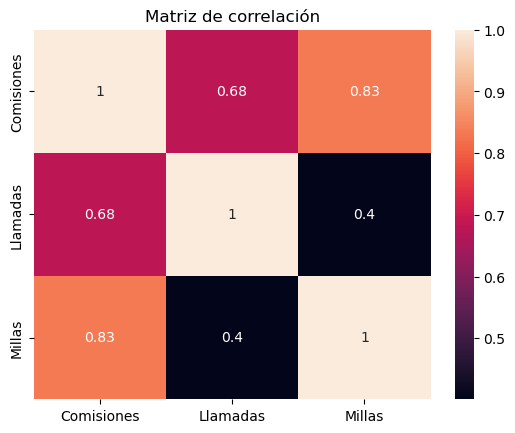

In [13]:
import seaborn as sns

plt.figure()
sns.heatmap(cor_matrix, annot=True)
plt.title("Matriz de correlación")
plt.show()

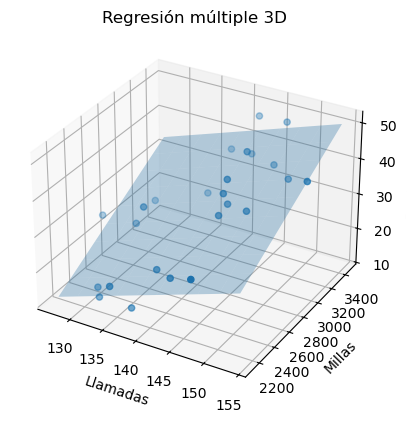

In [14]:
import numpy as np
import statsmodels.api as sm

# Variables
X = df[["Llamadas", "Millas"]]
X = sm.add_constant(X)
Y = df["Comisiones"]

modelo = sm.OLS(Y, X).fit()

# Crear malla para el plano
x_surf, y_surf = np.meshgrid(
    np.linspace(df["Llamadas"].min(), df["Llamadas"].max(), 10),
    np.linspace(df["Millas"].min(), df["Millas"].max(), 10)
)

exog = pd.DataFrame({
    "const": 1,
    "Llamadas": x_surf.ravel(),
    "Millas": y_surf.ravel()
})

z_surf = modelo.predict(exog)
z_surf = z_surf.values.reshape(x_surf.shape)

# Gráfica
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["Llamadas"], df["Millas"], df["Comisiones"])
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.3)

ax.set_xlabel("Llamadas")
ax.set_ylabel("Millas")
ax.set_zlabel("Comisiones")

plt.title("Regresión múltiple 3D")
plt.show()


In [8]:
r1, p1 = pearsonr(df["Comisiones"], df["Llamadas"])
print("r (Comisiones vs Llamadas):", r1)
print("p:", p1)

r (Comisiones vs Llamadas): 0.6797156955013889
p: 0.0001859882062041132


In [9]:
r2, p2 = pearsonr(df["Comisiones"], df["Millas"])
print("r (Comisiones vs Millas):", r2)
print("p:", p2)

r (Comisiones vs Millas): 0.8322714071792505
p: 2.489084048057974e-07


## Análisis
La matriz de correlación muestra una fuerte relación positiva entre el número de llamadas y las comisiones obtenidas.
También existe una relación positiva entre las millas recorridas y las comisiones, aunque de menor intensidad.
Esto indica que los agentes que realizan más llamadas tienden a obtener mayores comisiones, y recorrer más millas también contribuye al aumento en las ventas.
Los valores p obtenidos son menores a 0.05, lo que indica que las relaciones son estadísticamente significativas.